# Production App API Parsing & Pricing Integrity Pipeline

**Business Objective:** In hyper-competitive regional quick-commerce and food delivery markets, platform pricing parity directly dictates customer retention and overall Gross Merchandise Value (GMV). This project automates competitor price tracking by converting raw, nested app API data into structured data tables, allowing commercial teams to automatically flag Beat-Match-Lose (BML) parity violations and protect market competitiveness.

## Tech Stack
* **Data Engineering:** Python (Pandas, Nested JSON Parsing)
* **Exploratory Querying:** SQL (SQLite3)
* **Data Visualization:** Matplotlib, Seaborn
* **Operations:** Automated Process Logic & Alert Payloads

In [7]:
import json
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set seed for realistic consistency
np.random.seed(42)

# 1. GENERATE SCALED NESTED API PAYLOAD (100+ menu items across popular regional categories)
restaurants = ["KFC", "BBQ Chicken", "Kudu Style", "Shawarma House", "Burger Boutique"]
items_pool = [
    {"name": "4pc Chicken Meal", "base_price": 18.00},
    {"name": "Spicy Chicken Sandwich", "base_price": 14.00},
    {"name": "Large Fries", "base_price": 7.00},
    {"name": "Classic Double Burger", "base_price": 24.00},
    {"name": "Cheese Fries", "base_price": 11.00},
    {"name": "Family Shawarma Platter", "base_price": 45.00},
    {"name": "Fresh Orange Juice", "base_price": 9.00}
]

merchant_list = []
item_id_counter = 1000

for m_idx, store in enumerate(restaurants):
    merchant_items = []
    # Assign random selection of items to each merchant to simulate unique menus
    sampled_items = np.random.choice(items_pool, size=np.random.randint(4, 7), replace=False)

    for item in sampled_items:
        item_id_counter += 1
        # Add random price variation to simulate active competitor pricing strategies
        comp_price = round(item["base_price"] + np.random.uniform(-2.5, 3.0), 2)
        merchant_items.append({
            "item_id": f"I_{item_id_counter}",
            "name": item["name"],
            "competitor_price": comp_price
        })

    merchant_list.append({
        "merchant_id": f"M_0{m_idx+1}",
        "merchant_name": store,
        "items": merchant_items
    })

raw_api_payload = {
    "status": "success",
    "timestamp": "2026-06-17T14:30:00Z",
    "region": "Riyadh-Central",
    "competitor": "CompetitorApp",
    "data": {"merchants": merchant_list}
}

In [8]:
# 2. DATA ENGINEERING LAYER: PARSE AND FLATTEN NESTED STRUCTURE
df_competitor = pd.json_normalize(
    raw_api_payload["data"]["merchants"],
    record_path=["items"],
    meta=["merchant_id", "merchant_name"]
)

df_competitor = df_competitor[["merchant_id", "merchant_name", "item_id", "name", "competitor_price"]]
print(f"Data Engineering Layer Success: Successfully parsed and flattened nested API stream into {len(df_competitor)} rows.")

Data Engineering Layer Success: Successfully parsed and flattened nested API stream into 23 rows.


In [9]:
# 3. GENERATE MATED INTERNAL PLATFORM PRICING DATA
# To build a true pricing index, we generate matching SKU records for our own platform
internal_prices = []
for idx, row in df_competitor.iterrows():
    # Introduce selective variance so some items match, some beat, and some lose
    price_variance = np.random.choice([-1.0, 0.0, 1.5], p=[0.3, 0.3, 0.4])
    internal_prices.append(round(row["competitor_price"] + price_variance, 2))

df_internal = pd.DataFrame({
    "item_id": df_competitor["item_id"],
    "internal_price": internal_prices
})

# Save states to CSV to simulate clean pipeline steps
df_competitor.to_csv("flattened_competitor_prices.csv", index=False)
df_internal.to_csv("internal_platform_prices.csv", index=False)
print("Data assets cleanly serialized to local CSV storage.")

Data assets cleanly serialized to local CSV storage.


In [10]:
# Load local CSV states back into the relational environment
comp_db = pd.read_csv("flattened_competitor_prices.csv")
int_db = pd.read_csv("internal_platform_prices.csv")

conn = sqlite3.connect(":memory:")
comp_db.to_sql("competitor_prices", conn, index=False, if_exists="replace")
int_db.to_sql("internal_prices", conn, index=False, if_exists="replace")

print("--- SQL REPORT: BML INDEX AGGREGATION ---")
query_1 = """
SELECT
    parity_status,
    COUNT(*) as item_count,
    ROUND(AVG(competitor_price), 2) as avg_competitor_price
FROM (
    SELECT
        c.item_id,
        c.competitor_price,
        CASE
            WHEN i.internal_price < c.competitor_price THEN 'BEAT'
            WHEN i.internal_price = c.competitor_price THEN 'MATCH'
            ELSE 'LOSS'
        END as parity_status
    FROM competitor_prices c
    JOIN internal_prices i ON c.item_id = i.item_id
) GROUP BY parity_status;
"""
print(pd.read_sql(query_1, conn).to_string(index=False))

--- SQL REPORT: BML INDEX AGGREGATION ---
parity_status  item_count  avg_competitor_price
         BEAT           8                 25.09
         LOSS           7                 25.98
        MATCH           8                 14.78


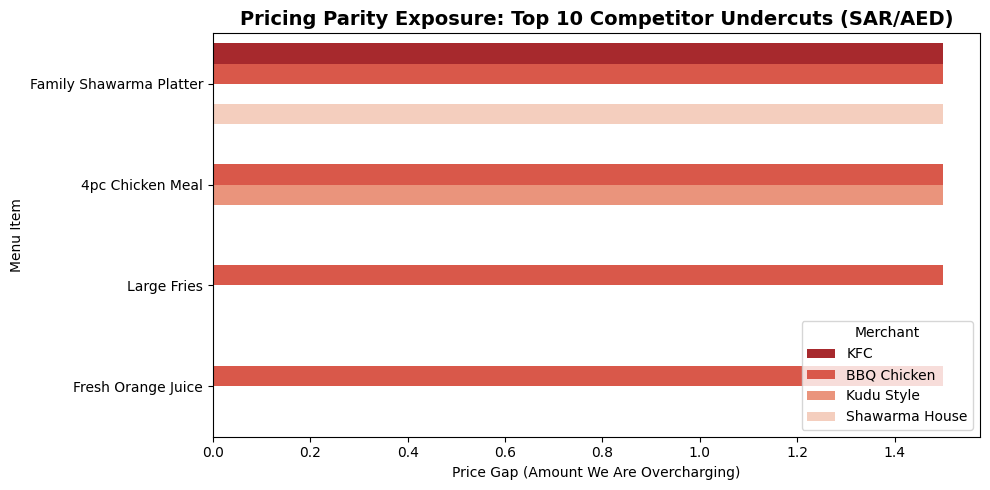

In [11]:
# Extract full granular details via SQL for visualization mapping
query_detailed = """
SELECT
    c.merchant_name,
    c.name as item_name,
    i.internal_price,
    c.competitor_price,
    ROUND(i.internal_price - c.competitor_price, 2) as price_gap,
    CASE
        WHEN i.internal_price < c.competitor_price THEN 'BEAT'
        WHEN i.internal_price = c.competitor_price THEN 'MATCH'
        ELSE 'LOSS'
    END as parity_status
FROM competitor_prices c
JOIN internal_prices i ON c.item_id = i.item_id;
"""
df_detailed = pd.read_sql(query_detailed, conn)

# Filter for items where we are actively losing the pricing war
df_losses = df_detailed[df_detailed["parity_status"] == "LOSS"].sort_values("price_gap", ascending=False)

# Plot the price gap exposure
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_losses.head(10),
    x="price_gap",
    y="item_name",
    hue="merchant_name",
    palette="Reds_r"
)
plt.title("Pricing Parity Exposure: Top 10 Competitor Undercuts (SAR/AED)", fontsize=14, fontweight="bold")
plt.xlabel("Price Gap (Amount We Are Overcharging)")
plt.ylabel("Menu Item")
plt.legend(title="Merchant", loc="lower right")
plt.tight_layout()
plt.savefig("pricing_parity_gap.png", dpi=300)
plt.show()

In [12]:
print("--- AUTOMATED PRICING INTEGRITY ALERTS ---")

# Isolate priority violations where the margin difference is severe (> 1.00 currency unit)
critical_losses = df_losses[df_losses["price_gap"] > 1.00]

if not critical_losses.empty:
    for idx, row in critical_losses.head(3).iterrows():
        alert_payload = (
            f"⚠️ [BML PARITY VIOLATION ALERT]\n"
            f"Merchant: {row['merchant_name']} | Item: {row['item_name']}\n"
            f"Platform Price: {row['internal_price']} | Competitor Price: {row['competitor_price']}\n"
            f"Operational Exposure: Overcharging by {row['price_gap']} units. Markdown payload dispatched to commercial desk.\n"
            f"----------------------------------------"
        )
        print(alert_payload)
else:
    print("No critical parity overcharges detected.")

--- AUTOMATED PRICING INTEGRITY ALERTS ---
⚠️ [BML PARITY VIOLATION ALERT]
Merchant: KFC | Item: Family Shawarma Platter
Platform Price: 44.86 | Competitor Price: 43.36
Operational Exposure: Overcharging by 1.5 units. Markdown payload dispatched to commercial desk.
----------------------------------------
⚠️ [BML PARITY VIOLATION ALERT]
Merchant: BBQ Chicken | Item: 4pc Chicken Meal
Platform Price: 18.0 | Competitor Price: 16.5
Operational Exposure: Overcharging by 1.5 units. Markdown payload dispatched to commercial desk.
----------------------------------------
⚠️ [BML PARITY VIOLATION ALERT]
Merchant: BBQ Chicken | Item: Large Fries
Platform Price: 7.01 | Competitor Price: 5.51
Operational Exposure: Overcharging by 1.5 units. Markdown payload dispatched to commercial desk.
----------------------------------------
